# Task 3: Superstore Exploratory Data Analysis

This hypothesis-driven EDA prepares order-level Superstore data, examines category, seasonality, segment, discount, and regional performance, then produces publication-quality charts.

> **Google Colab:** Upload `Task 3` to `MyDrive/Thiranex/Task 3` and run every cell.


In [1]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q pandas numpy matplotlib seaborn
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    candidates = [Path('/content/drive/MyDrive/Thiranex/Task 3'), Path('/content/drive/MyDrive/Task 3'), Path('/content/Task 3')]
    PROJECT_ROOT = next((path for path in candidates if path.exists()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError('Upload Task 3 to MyDrive/Thiranex/Task 3 and rerun.')
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from analysis import business_tables
from data_cleaning import run_preparation_pipeline
from visualization import generate_figures

RAW_PATH = PROJECT_ROOT / 'data/raw/task3_data.csv'
PROCESSED_PATH = PROJECT_ROOT / 'data/processed/task3_prepared.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports/figures'
print(f'Project root: {PROJECT_ROOT}')


C:\Users\Syed Imad Muzaffar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 3


## 1. Audit and Preparation

We validate the source shape, missing values, and duplicate records. Dates are parsed using the documented month/day/year format; derived calendar and margin fields make temporal and profitability analysis reproducible.


In [2]:
raw_df, df, audit, preparation_log = run_preparation_pipeline(RAW_PATH, PROCESSED_PATH)
print('Raw shape:', audit['shape'])
print('Missing values:', audit['missing_values'])
print('Exact duplicate rows:', audit['duplicate_rows'])
print('Derived features:', preparation_log['new_features'])
display(df.head())


Raw shape: (10194, 21)
Missing values: {}
Exact duplicate rows: 0
Derived features: ['Order Year', 'Order Month', 'Order Quarter', 'Shipping Days', 'Profit Margin']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Shipping Days,Profit Margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,2023-01,Q1,4,0.3375
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,2023-01,Q1,4,-1.5500
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,2023,2023-01,Q1,4,0.3625
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,2023-01,Q1,4,-0.2375
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,2023-01,Q1,7,0.2500


## 2. Business Questions and Multivariate Tables

1. Does Technology have a higher profit margin than Furniture?
2. What do monthly and quarterly sales trends reveal?
3. Which segment delivers the highest average order value?
4. How does discount level affect profitability?
5. Which regions produce the most profit?


In [3]:
tables = business_tables(df)

print('Category performance')
display(tables['category'].style.format({'total_sales': '${:,.0f}', 'total_profit': '${:,.0f}', 'profit_margin': '{:.1%}'}))
print('Segment order value')
display(tables['segment'].style.format({'average_order_value': '${:,.2f}'}))
print('Regional performance')
display(tables['region'].style.format({'total_sales': '${:,.0f}', 'total_profit': '${:,.0f}', 'profit_margin': '{:.1%}'}))
print('Discount impact')
display(tables['discount'].style.format({'average_profit': '${:,.2f}', 'total_sales': '${:,.0f}'}))


Category performance


,total_sales,total_profit,profit_margin
Category,,,
Technology,"$839,893","$146,543",17.4%
Office Supplies,"$731,893","$126,023",17.2%
Furniture,"$754,748","$19,730",2.6%


Segment order value


,average_order_value,order_count
Segment,,
Home Office,$472.68,931
Corporate,$461.22,1552
Consumer,$445.46,2628


Regional performance


,total_sales,total_profit,profit_margin
Region,,,
West,"$739,814","$110,799",15.0%
East,"$691,828","$94,883",13.7%
South,"$391,722","$46,749",11.9%
Central,"$503,171","$39,865",7.9%


Discount impact


,average_profit,total_sales,line_items
Discount,,,
0.000000,$66.34,"$1,105,324",4925
0.100000,$94.79,"$54,952",96
0.150000,$27.29,"$27,559",52
0.200000,$24.58,"$773,939",3706
0.300000,$-45.71,"$104,474",230
0.320000,$-88.56,"$14,493",27
0.400000,$-111.53,"$116,498",207
0.450000,$-226.65,"$5,485",11
0.500000,$-310.70,"$58,919",66


## 3. Trends, Patterns, and Correlations

The figures below capture changes over time, segment distributions, the nonlinear discount-profit relationship, regional performance, and numeric correlations. All exports are saved at 300 DPI in `reports/figures`.


01_category_profit_margin.png


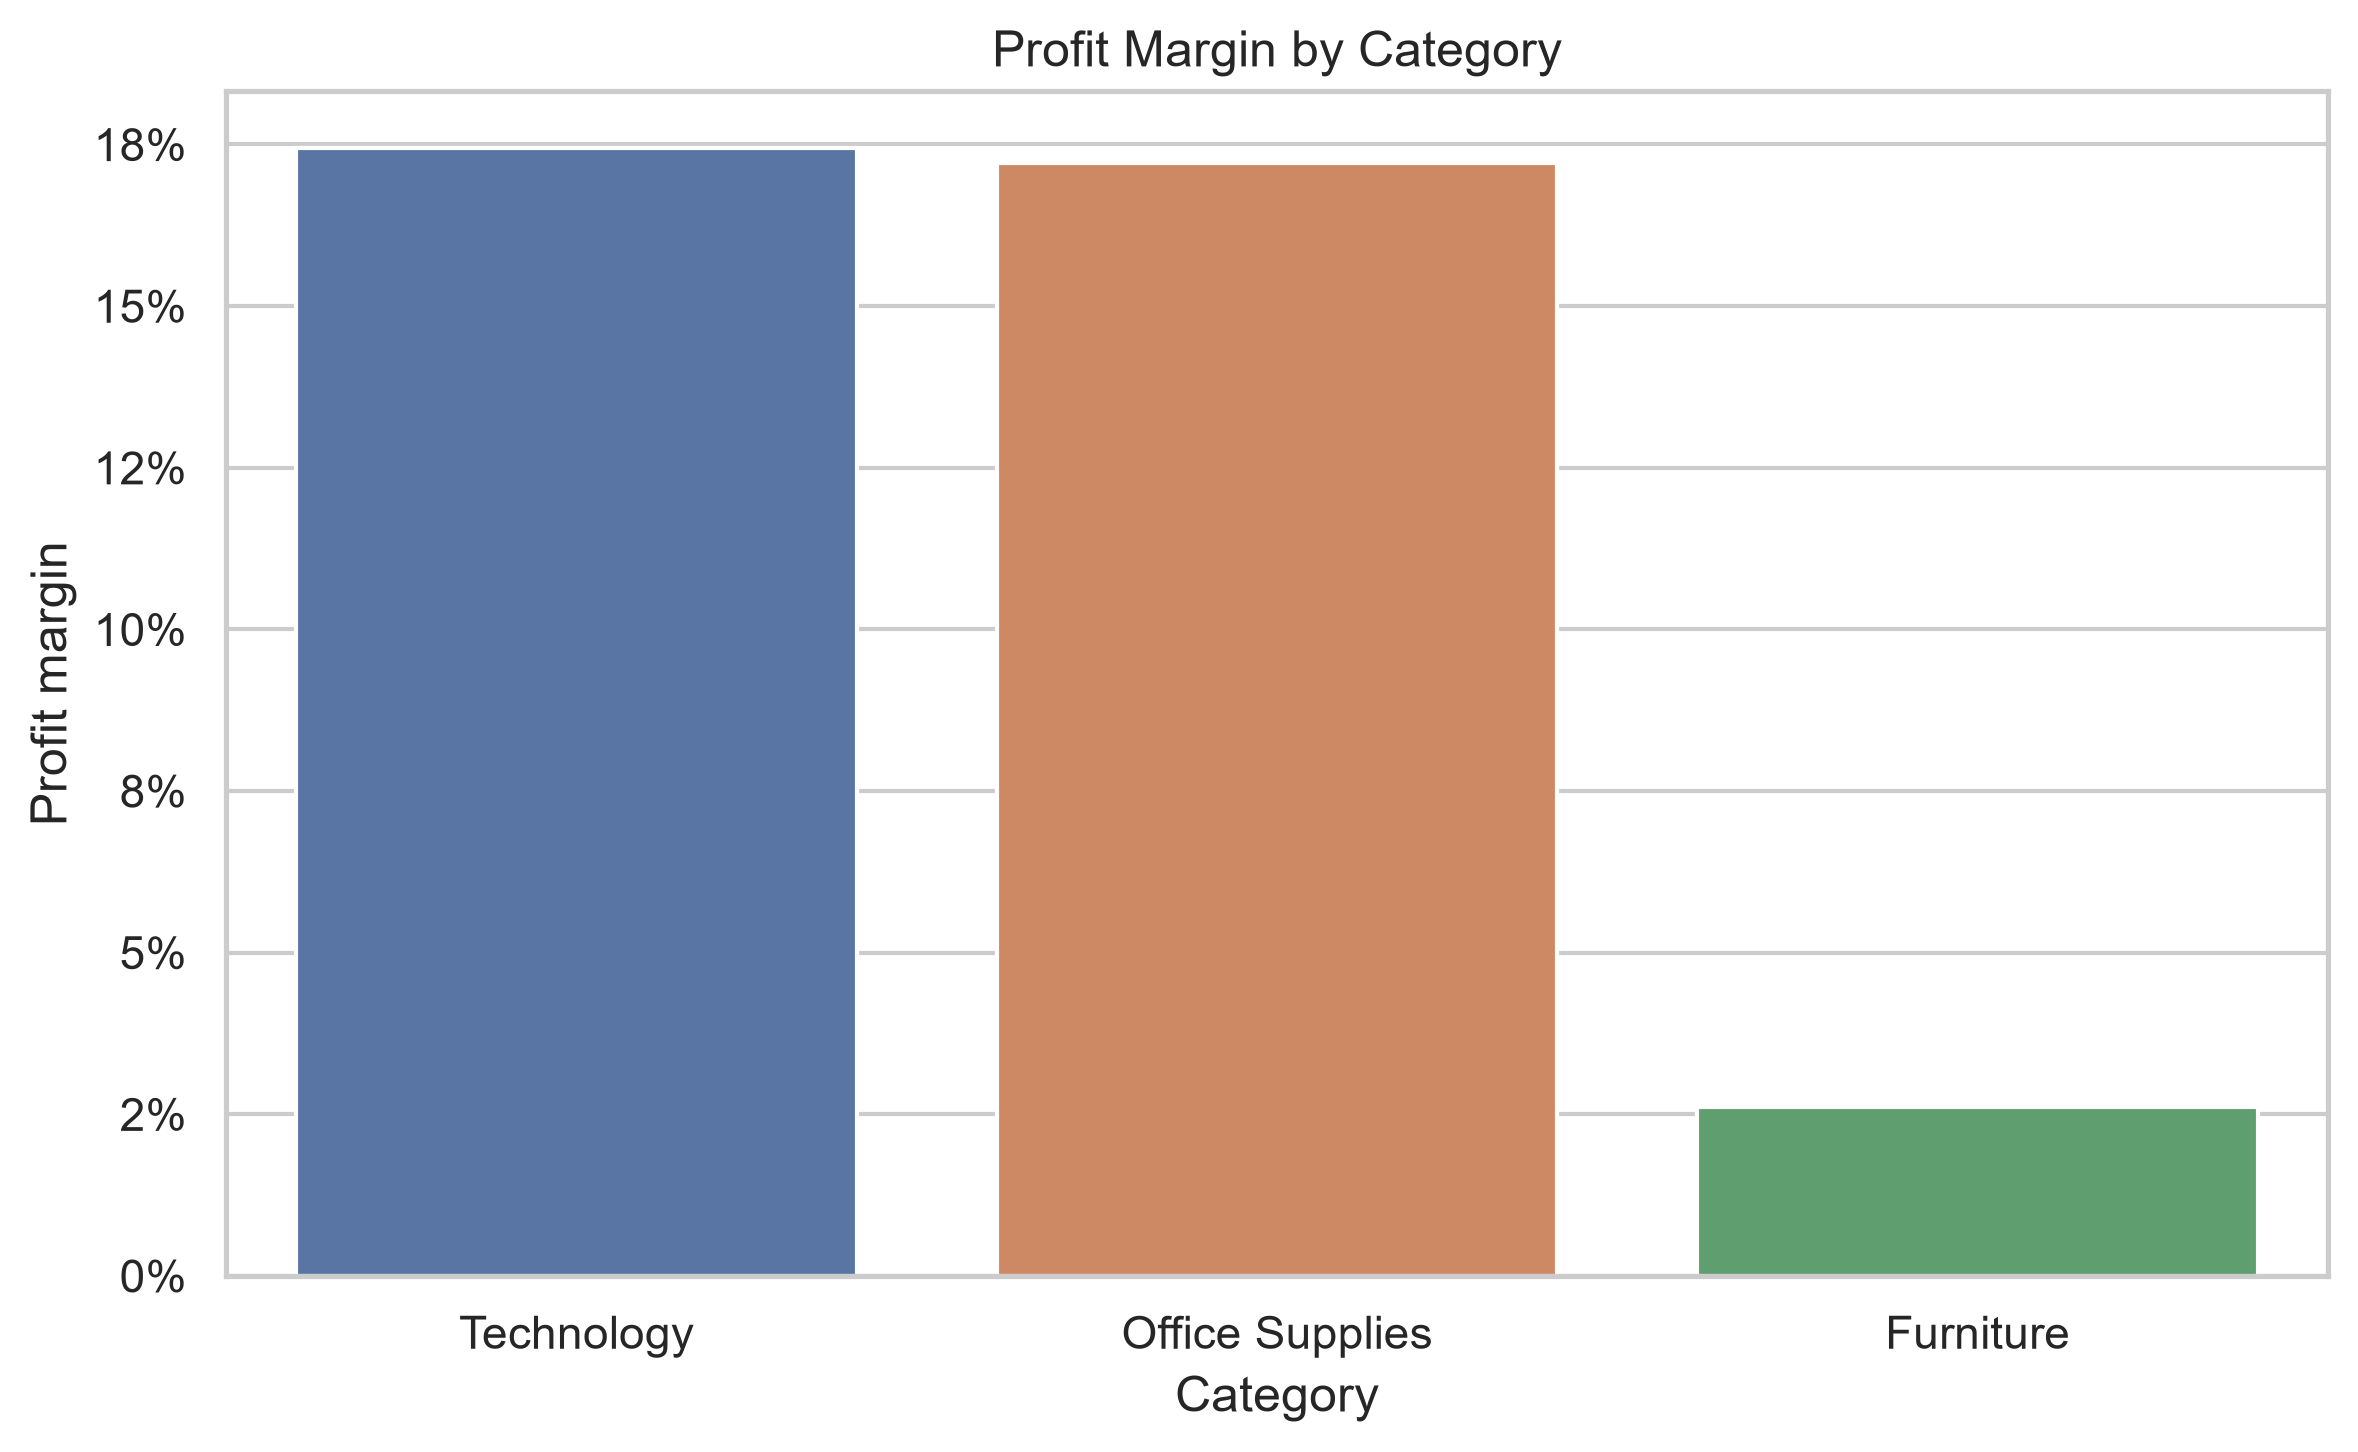

02_monthly_sales_trend.png


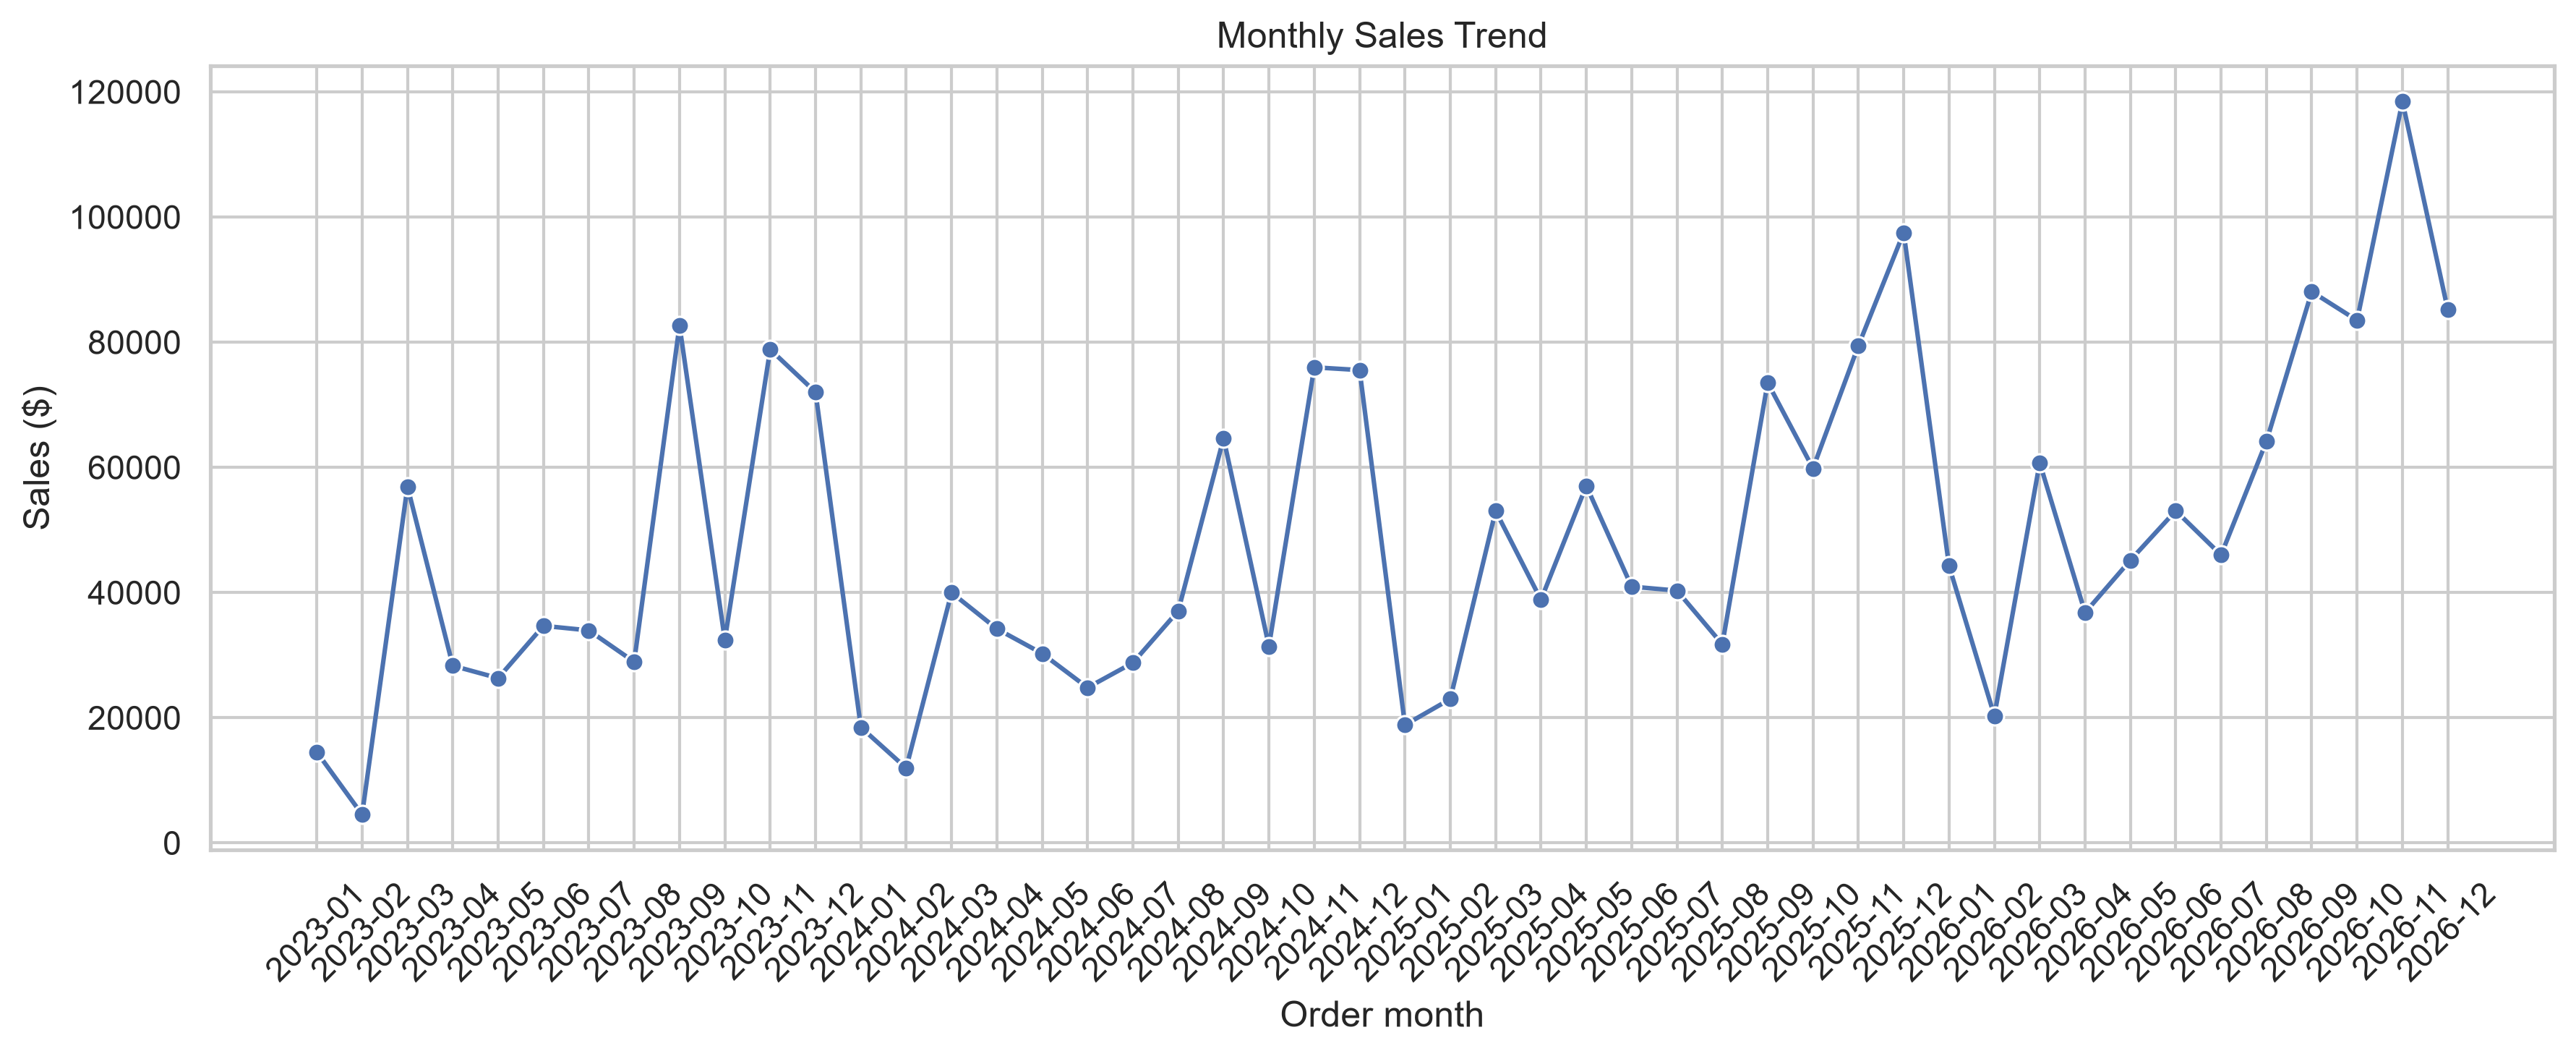

03_segment_sales_distribution.png


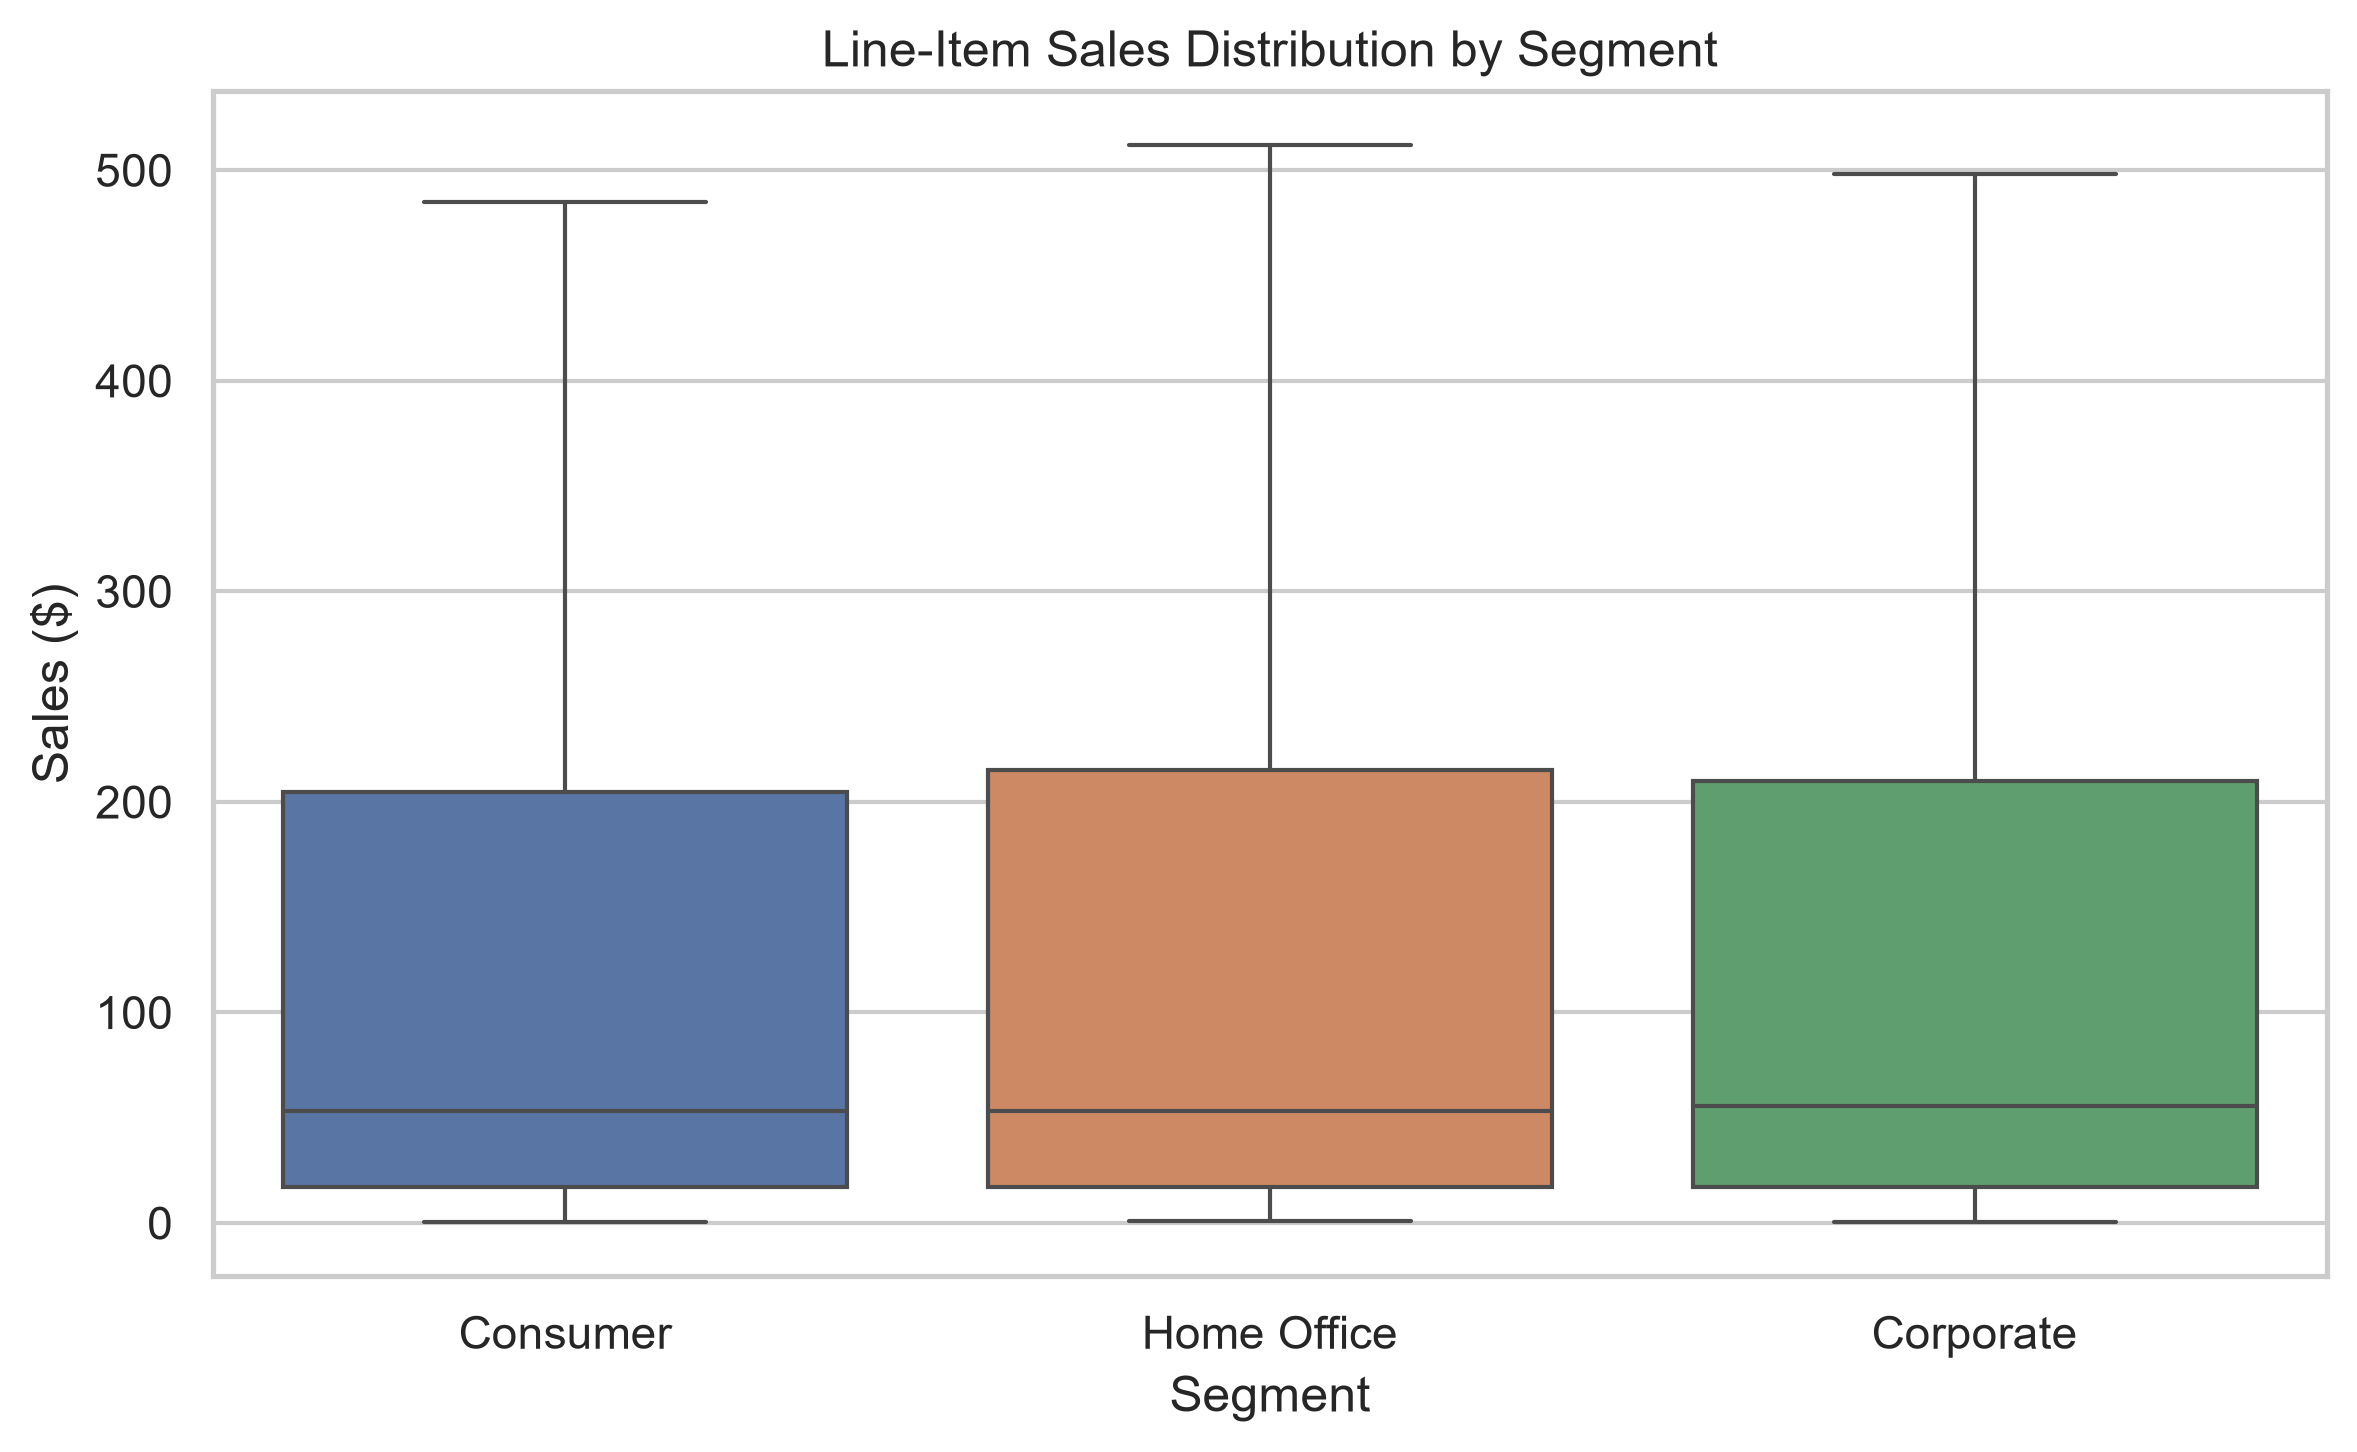

04_discount_profit.png


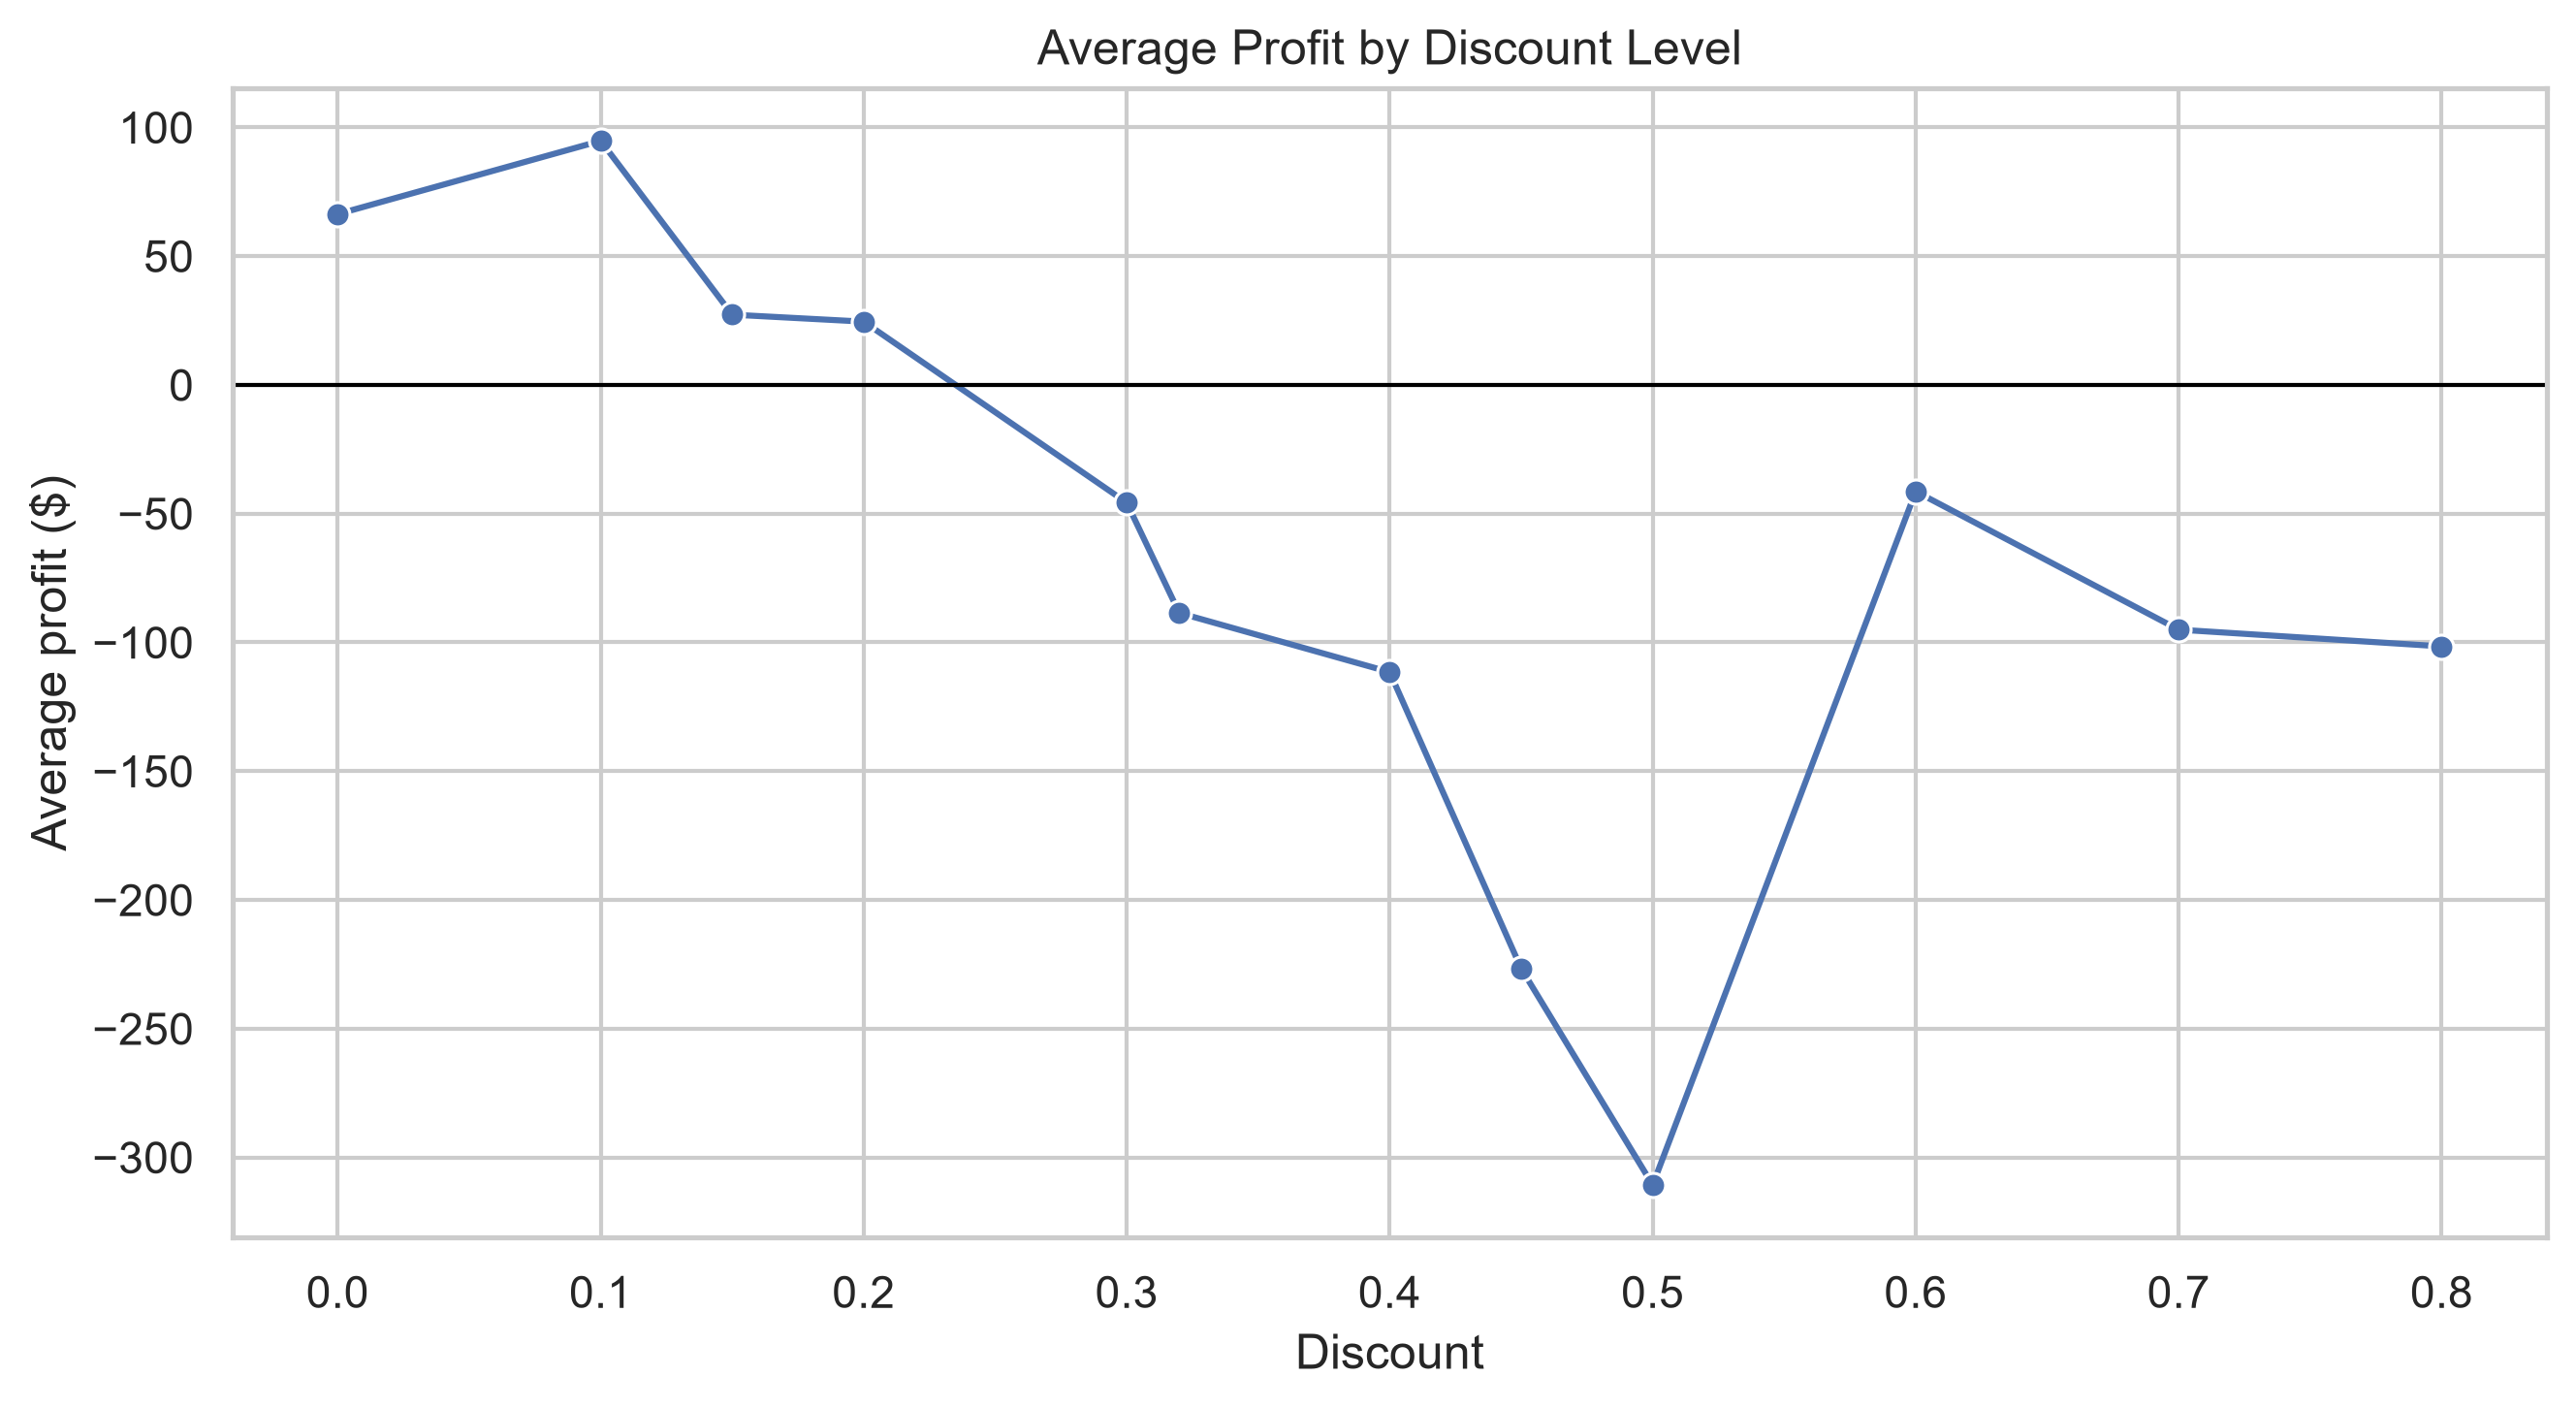

05_regional_profit.png


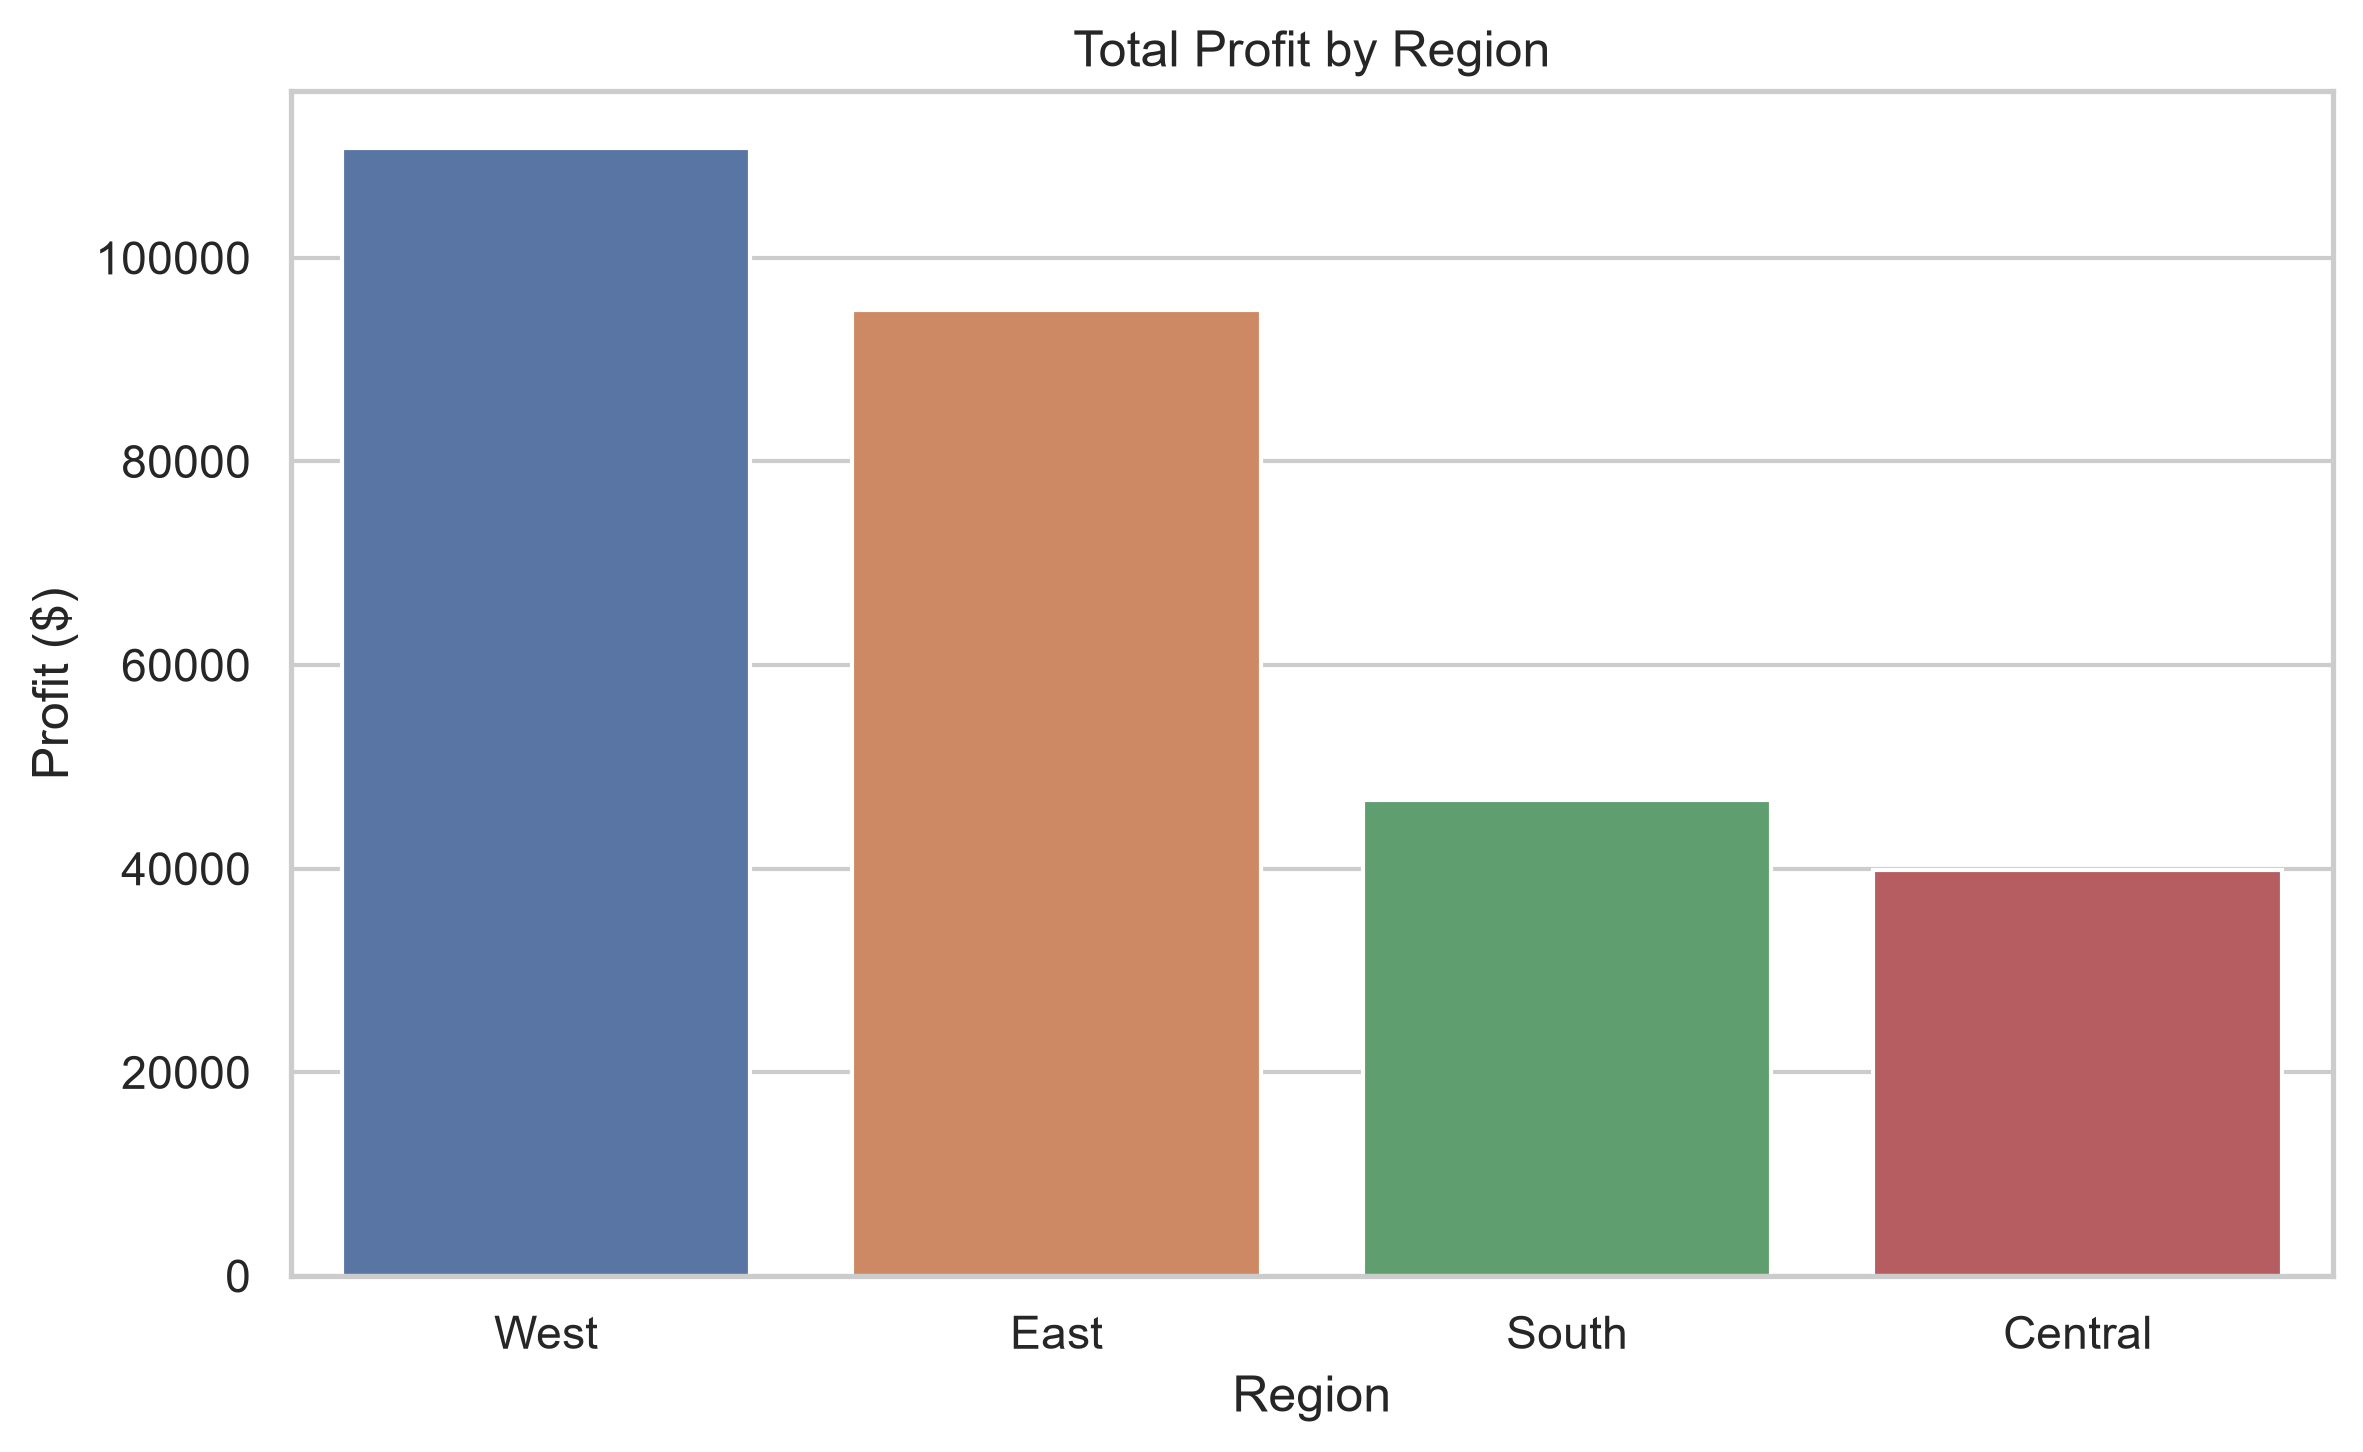

06_correlation_heatmap.png


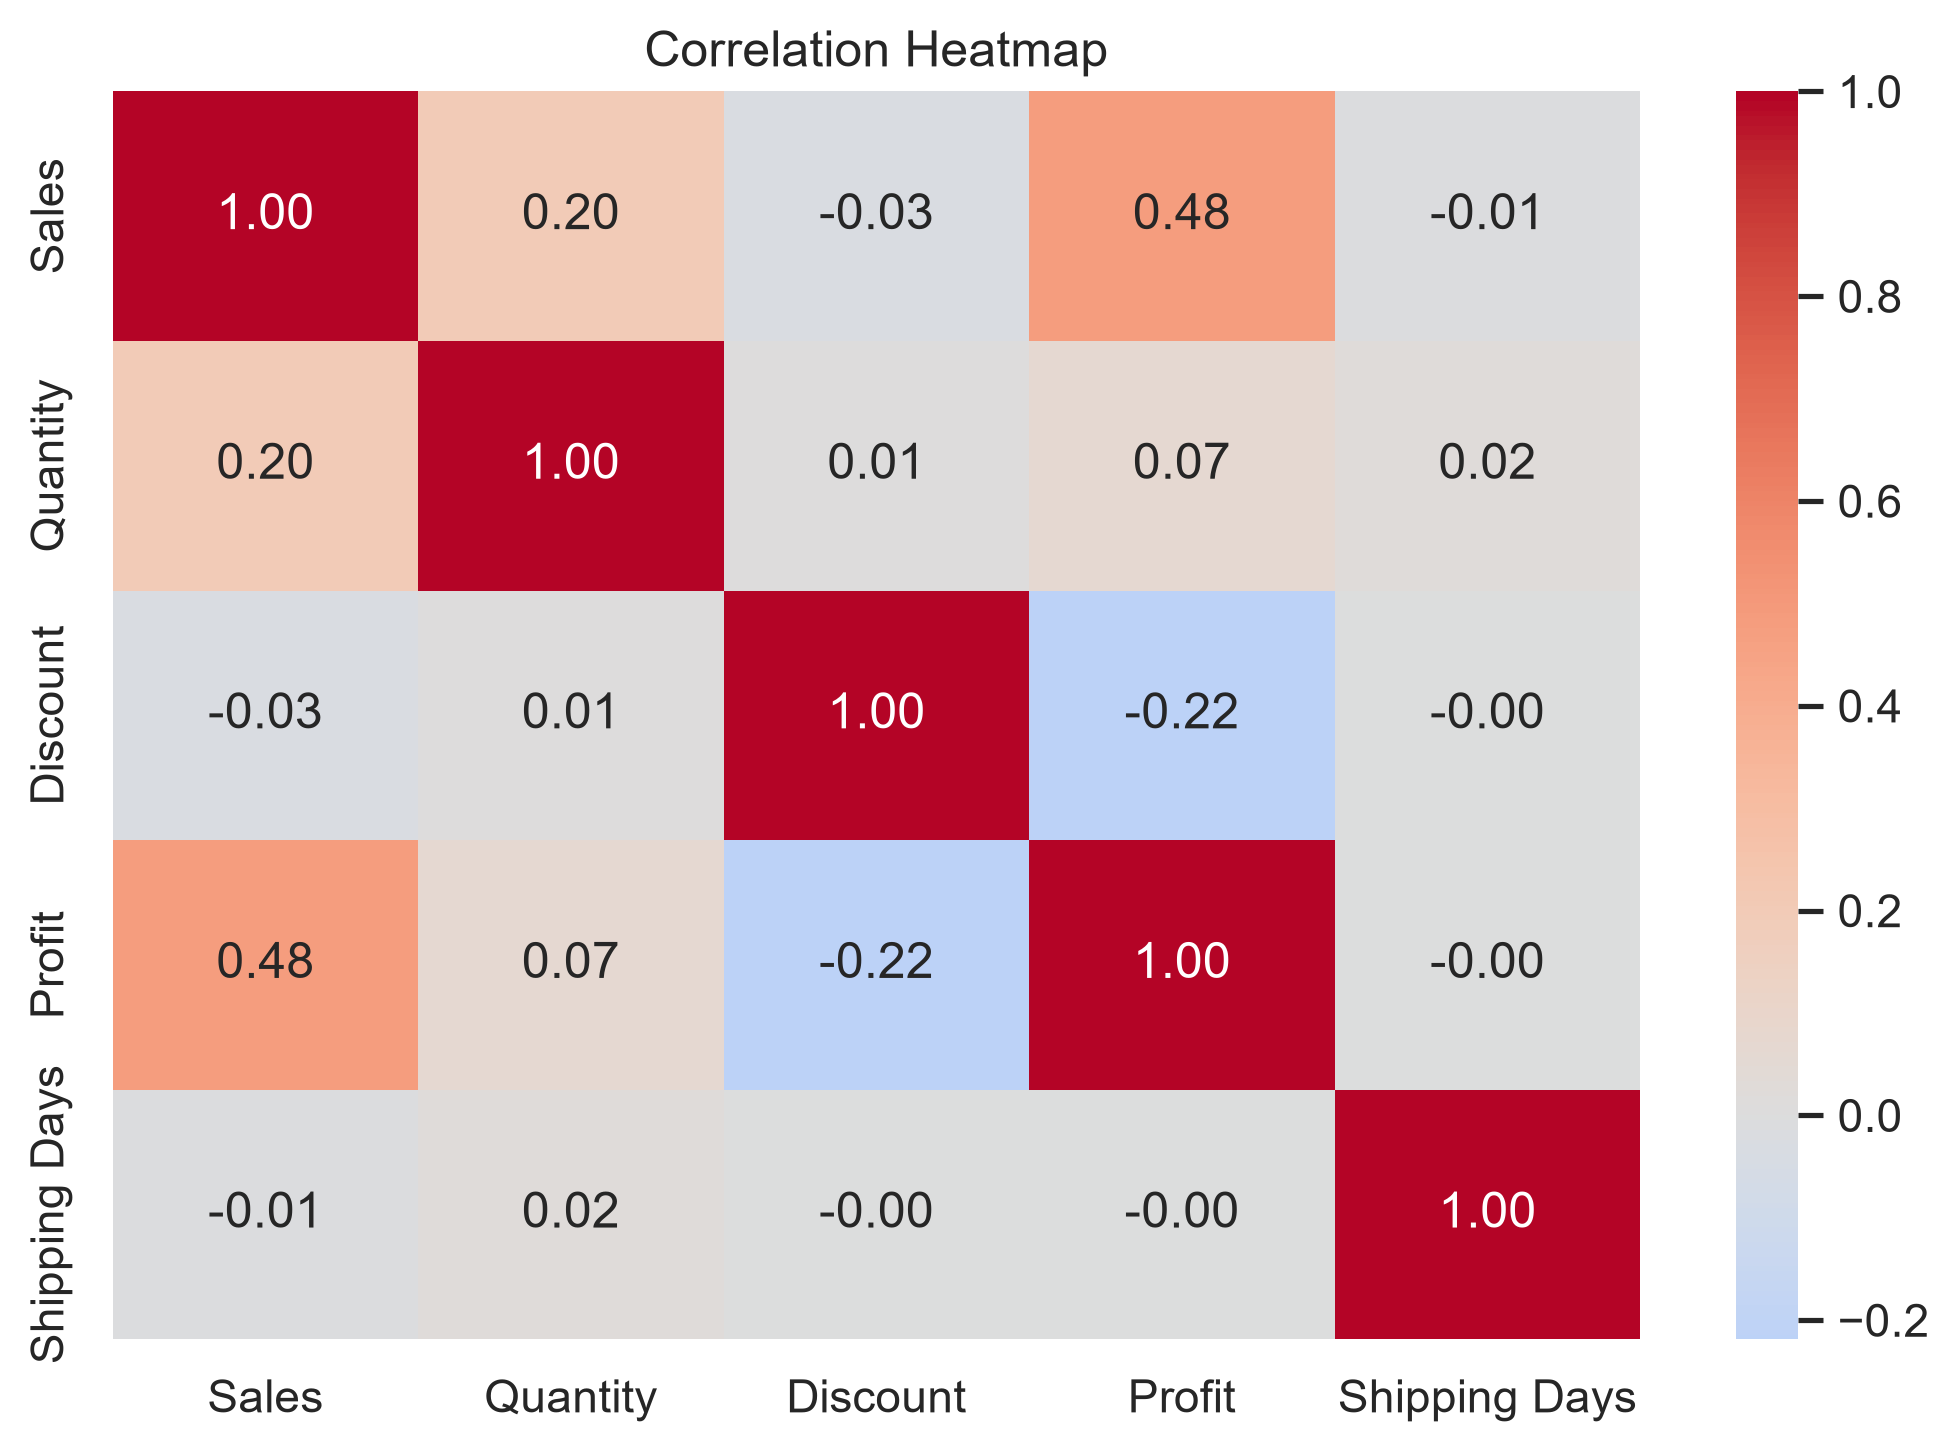

In [4]:
from IPython.display import Image, display

figure_paths = generate_figures(df, tables, FIGURES_DIR)
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path)))


## 4. Executive Recommendations

- Protect Technology and Office Supplies margin; investigate Furniture’s low 2.6% aggregate margin.
- Use the West’s $110.8K profit performance as a benchmark for regional operating decisions.
- Treat discounts of 30% or greater as an exception path: average profit becomes negative at that level.
- Use the monthly trend for inventory and campaign timing, while accounting for variation across the 2023–2026 study period.
